# Textual Analysis — Newspaper Headlines (2024 US Presidential Election)

Data: **151 000+ articles** from 187 outlets (scraped + MediaCloud), Jul–Nov 2024, stored in `2_Silver`.

**Pipeline (following Lecture 2 — Text Mining):**
1. Load & inspect combined dataset
2. Text preprocessing — vocabulary reduction stats
3. Word clouds: raw → preprocessed → TF-IDF weighted
4. TF-IDF analysis — most distinctive words per leaning
5. SVD / Latent Semantic Analysis — dimensionality reduction
6. Word co-occurrence network — communities & centrality
7. Key term frequency over time

In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from wordcloud import WordCloud
import networkx as nx

# ── Data path ────────────────────────────────────────────────────────────────
DATA = "../../Data/2_Silver/Newspapers/newspaper_articles_combined.csv"

# ── Load combined dataset ─────────────────────────────────────────────────────
df = pd.read_csv(DATA, parse_dates=["date"])
print(f"Total articles : {len(df):,}")
print(f"Date range     : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique sources : {df['source'].nunique()}\n")
print(df.groupby("leaning").size().sort_values(ascending=False).to_string())
df.head(3)

Total articles : 151,402
Date range     : 2024-07-05 → 2024-11-04
Unique sources : 187

leaning
Center/Unknown    64438
Democratic        55372
Republican        31592


,source,leaning,date,title,url
0,The Guardian,Democratic,2024-07-05,Ukraine war briefing: Ukrainian army confirms ...,https://www.theguardian.com/world/article/2024...
1,Political Wire,Center/Unknown,2024-07-05,Biden Cancels Speech at Teacher’s Union Conven...,https://politicalwire.com/2024/07/05/biden-can...
2,Rolling Stone,Democratic,2024-07-05,Biden Emphatically Insists He’s Staying in Rac...,https://www.rollingstone.com/politics/politics...


**Interpretation:** The dataset covers 151,402 articles from 187 outlets over the full 4-month run-up to Election Day. Center/Unknown outlets account for 42.6% of articles, Democratic-leaning for 36.6%, and Republican-leaning for 20.9%. The Republican underrepresentation reflects the media landscape: left-leaning and centrist outlets are more numerous and produce higher article volumes than right-leaning ones. **This imbalance should be kept in mind when comparing TF-IDF scores and frequencies across leanings.**

## 1. Text Preprocessing

Pipeline: lowercase → remove punctuation → remove numbers → collapse whitespace → remove stopwords.
We measure vocabulary reduction at each step to quantify the impact.

In [13]:
# ── Stopwords ─────────────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
custom_stops = {
    'says', 'say', 'said', 'new', 'one', 'two', 'us', 'year', 'years',
    'time', 'would', 'could', 'also', 'like', 'get', 'got', 'will', 'may',
    'back', 'way', 'first', 'last', 'week', 'day', 'make', 'show', 'know',
    'take', 'come', 'go', 'see', 'look', 'need', 'trump', 'harris',
    'kamala', 'donald',  # dominant candidates — excluded from clouds only
}
stop_words = stop_words.union(custom_stops)

# ── Preprocessing function ────────────────────────────────────────────────────
def preprocess(text_series):
    """Lowercase → remove punctuation → remove numbers → collapse whitespace."""
    return (
        text_series
        .fillna('')
        .str.lower()
        .str.replace(r'[^\w\s]', ' ', regex=True)
        .str.replace(r'\d+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

# ── Vocabulary reduction stats ────────────────────────────────────────────────
raw_tokens   = df['title'].fillna('').str.cat(sep=' ').split()
raw_vocab    = len(set(raw_tokens))

df['title_clean'] = preprocess(df['title'])
clean_tokens = df['title_clean'].str.cat(sep=' ').split()
clean_vocab  = len(set(clean_tokens))

# After stopword removal
nostop_tokens = [t for t in clean_tokens if t not in stop_words and len(t) >= 3]
nostop_vocab  = len(set(nostop_tokens))

print("Vocabulary reduction through preprocessing:")
print(f"  Raw text            : {raw_vocab:,} unique tokens")
print(f"  After preprocessing : {clean_vocab:,} unique tokens  ({(1-clean_vocab/raw_vocab)*100:.1f}% reduction)")
print(f"  After stopwords     : {nostop_vocab:,} unique tokens  ({(1-nostop_vocab/raw_vocab)*100:.1f}% reduction)")
print()
print("Sample titles (raw → clean):")
df[['title','title_clean']].head(4)

Vocabulary reduction through preprocessing:
  Raw text            : 116,817 unique tokens
  After preprocessing : 34,654 unique tokens  (70.3% reduction)
  After stopwords     : 34,159 unique tokens  (70.8% reduction)

Sample titles (raw → clean):


,title,title_clean
0,Ukraine war briefing: Ukrainian army confirms ...,ukraine war briefing ukrainian army confirms r...
1,Biden Cancels Speech at Teacher’s Union Conven...,biden cancels speech at teacher s union conven...
2,Biden Emphatically Insists He’s Staying in Rac...,biden emphatically insists he s staying in rac...
3,Trump Stays Relatively Quiet,trump stays relatively quiet


**Interpretation:** Preprocessing alone (lowercasing + punctuation/number removal) cuts the vocabulary by 70.3% — from 116,817 to 34,654 unique tokens. This large drop is mainly driven by case normalisation collapsing capitalised variants (e.g. "Trump" and "trump") into one token. Adding stopword removal only yields an additional 0.5% reduction, which is typical for news headlines: they are already terse, containing few filler words. The remaining ~34,000 tokens form the working vocabulary for all downstream analyses.

## 2. Word Clouds

Three levels following the lecture, shown for **all 4 groups**: Overall, Democratic, Republican, Center/Unknown.
- **Raw**: no preprocessing — shows noise and dominant surface words
- **Preprocessed**: lowercase + punctuation/number removal + stopwords removed
- **TF-IDF weighted**: highlights words *distinctive* per group, not just frequent

> *Interpretation note (theory):* Raw clouds reflect surface frequency biases. TF-IDF clouds are more analytically valuable because they suppress words common across all outlets and surface what makes each group's vocabulary unique.

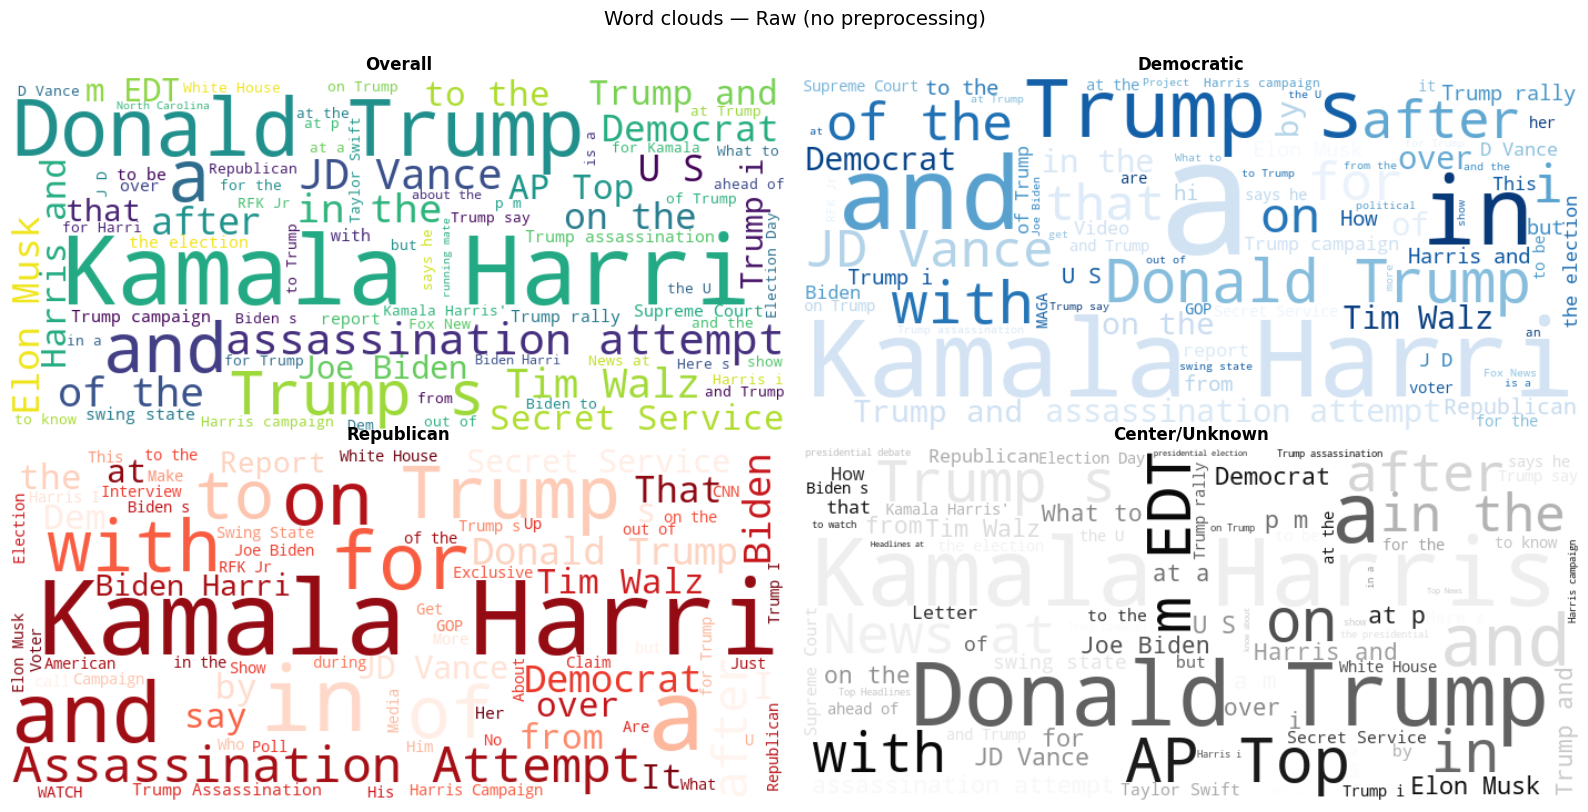

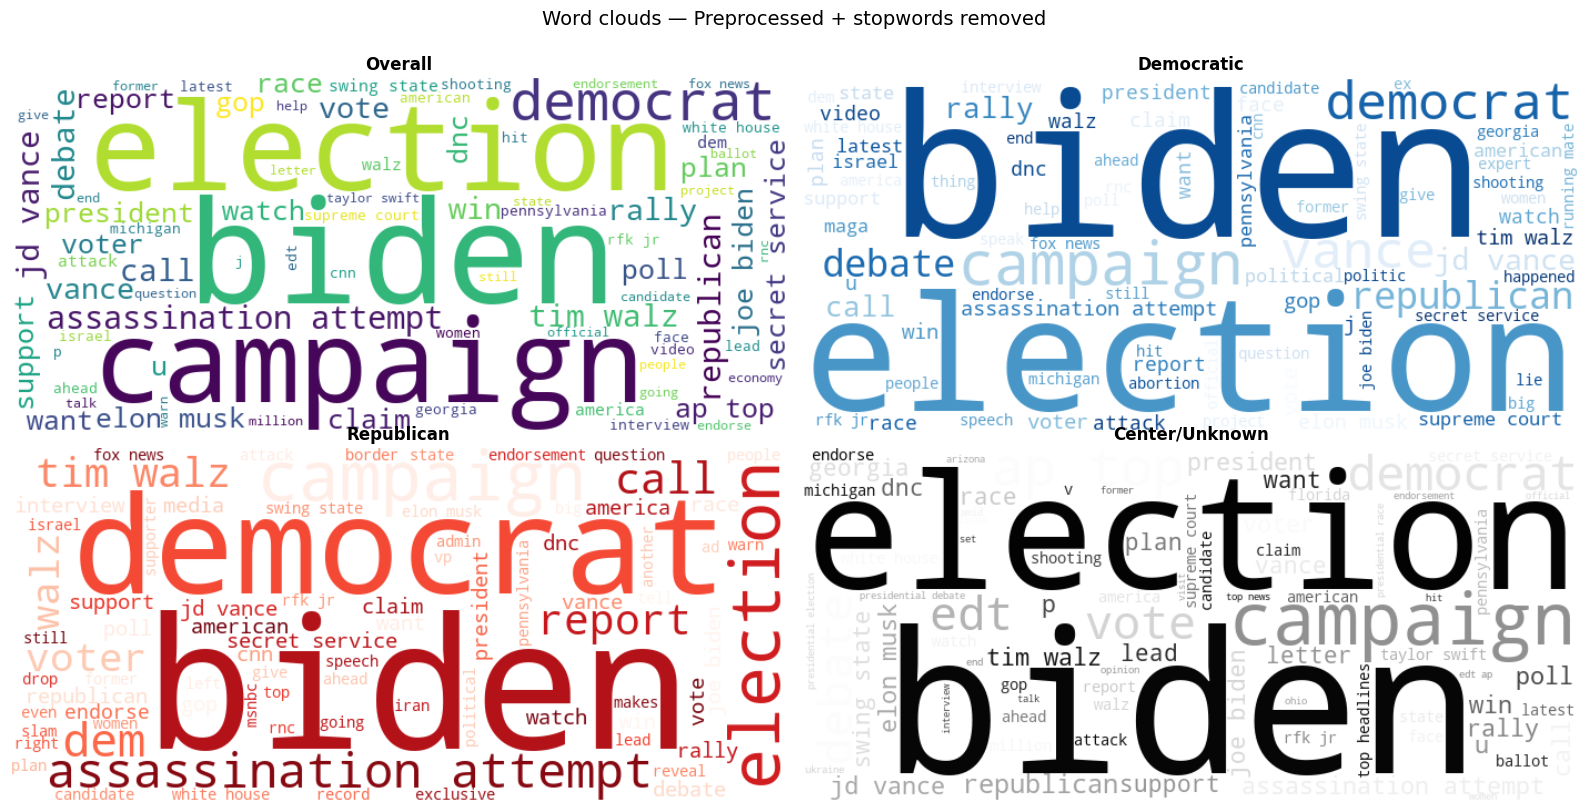

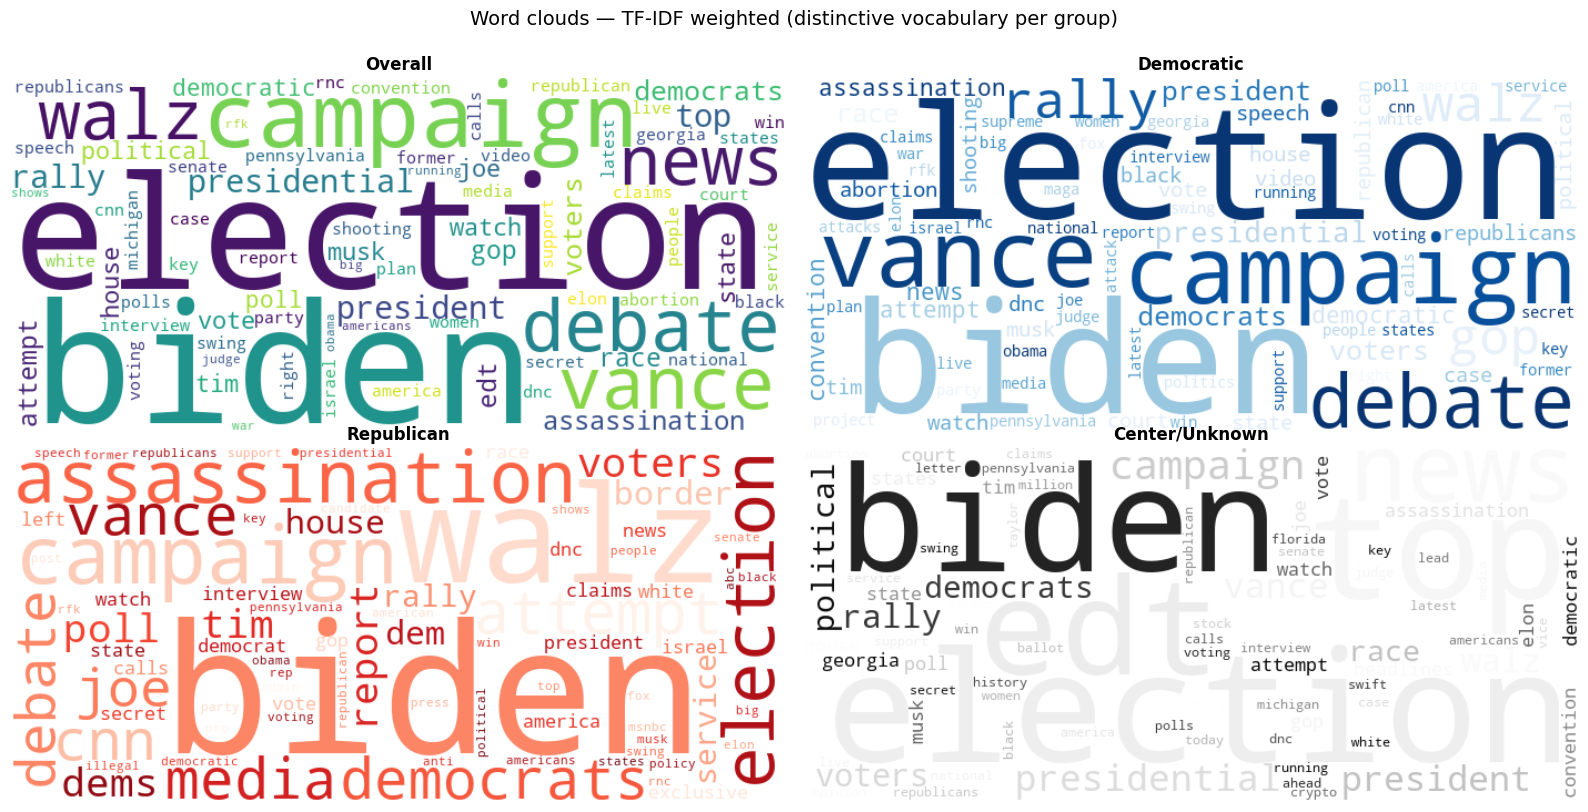

In [14]:
ALL_GROUPS = {
    'Overall':        df,
    'Democratic':     df[df['leaning'] == 'Democratic'],
    'Republican':     df[df['leaning'] == 'Republican'],
    'Center/Unknown': df[df['leaning'] == 'Center/Unknown'],
}
colors_map = {
    'Overall':        'viridis',
    'Democratic':     'Blues',
    'Republican':     'Reds',
    'Center/Unknown': 'Greys',
}

def make_wc(text, stopwords_set, colormap):
    return WordCloud(width=700, height=320, background_color='white',
                     stopwords=stopwords_set, max_words=80,
                     colormap=colormap, relative_scaling=0.4).generate(text)

def make_wc_tfidf(scores_dict, stopwords_set, colormap):
    return WordCloud(width=700, height=320, background_color='white',
                     stopwords=stopwords_set, max_words=80,
                     colormap=colormap, relative_scaling=0.4).generate_from_frequencies(scores_dict)

def plot_wc_grid(wc_dict, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    for ax, (label, wc) in zip(axes.flat, wc_dict.items()):
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(label, fontsize=12, fontweight='bold')
    plt.suptitle(suptitle, fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

# ── 2a. Raw ───────────────────────────────────────────────────────────────────
wc_raw = {label: make_wc(' '.join(sub['title'].fillna('')), set(), colors_map[label])
          for label, sub in ALL_GROUPS.items()}
plot_wc_grid(wc_raw, 'Word clouds — Raw (no preprocessing)')

# ── 2b. Preprocessed ─────────────────────────────────────────────────────────
wc_clean = {label: make_wc(' '.join(sub['title_clean']), stop_words, colors_map[label])
            for label, sub in ALL_GROUPS.items()}
plot_wc_grid(wc_clean, 'Word clouds — Preprocessed + stopwords removed')

# ── 2c. TF-IDF weighted ───────────────────────────────────────────────────────
tfidf_wc = TfidfVectorizer(token_pattern=r'\b\w{3,}\b', stop_words=list(stop_words),
                            min_df=5, max_df=0.95, max_features=5000)
X_wc       = tfidf_wc.fit_transform(df['title_clean'])
feat_names = tfidf_wc.get_feature_names_out()

wc_tfidf = {}
for label, sub in ALL_GROUPS.items():
    mask        = df.index.isin(sub.index)
    mean_scores = X_wc[mask].mean(axis=0).A1
    scores_dict = {feat_names[i]: mean_scores[i] for i in mean_scores.argsort()[::-1][:200]}
    wc_tfidf[label] = make_wc_tfidf(scores_dict, stop_words, colors_map[label])
plot_wc_grid(wc_tfidf, 'Word clouds — TF-IDF weighted (distinctive vocabulary per group)')

**Interpretation:**
- **Raw clouds** are dominated by candidate names and generic news words ("Trump", "Harris", "election", "says") — high frequency but low informativeness.
- **Preprocessed clouds** remove noise: policy and event terms become visible (e.g. "debate", "abortion", "immigration", "vote", "poll"), but shared vocabulary still dominates all groups.
- **TF-IDF clouds** are the most revealing: they suppress corpus-wide common words and surface each group's *distinctive* framing. 

## 3. TF-IDF Analysis — Most Distinctive Words per Leaning

TF-IDF (Term Frequency–Inverse Document Frequency) weights a word by how often it appears in a document relative to how common it is across *all* documents.

**Formula (log-smoothed):**
- `TF = log(1 + raw_tf)`
- `IDF = 1 + log(N / df_t)`
- `w_td = TF × IDF`

A high TF-IDF score means a word is **frequent in that outlet's articles but rare across the full corpus** — making it a reliable signal of that leaning's unique framing.

DTM shape   : 151,402 docs × 9,914 terms
Sparsity    : 99.9%



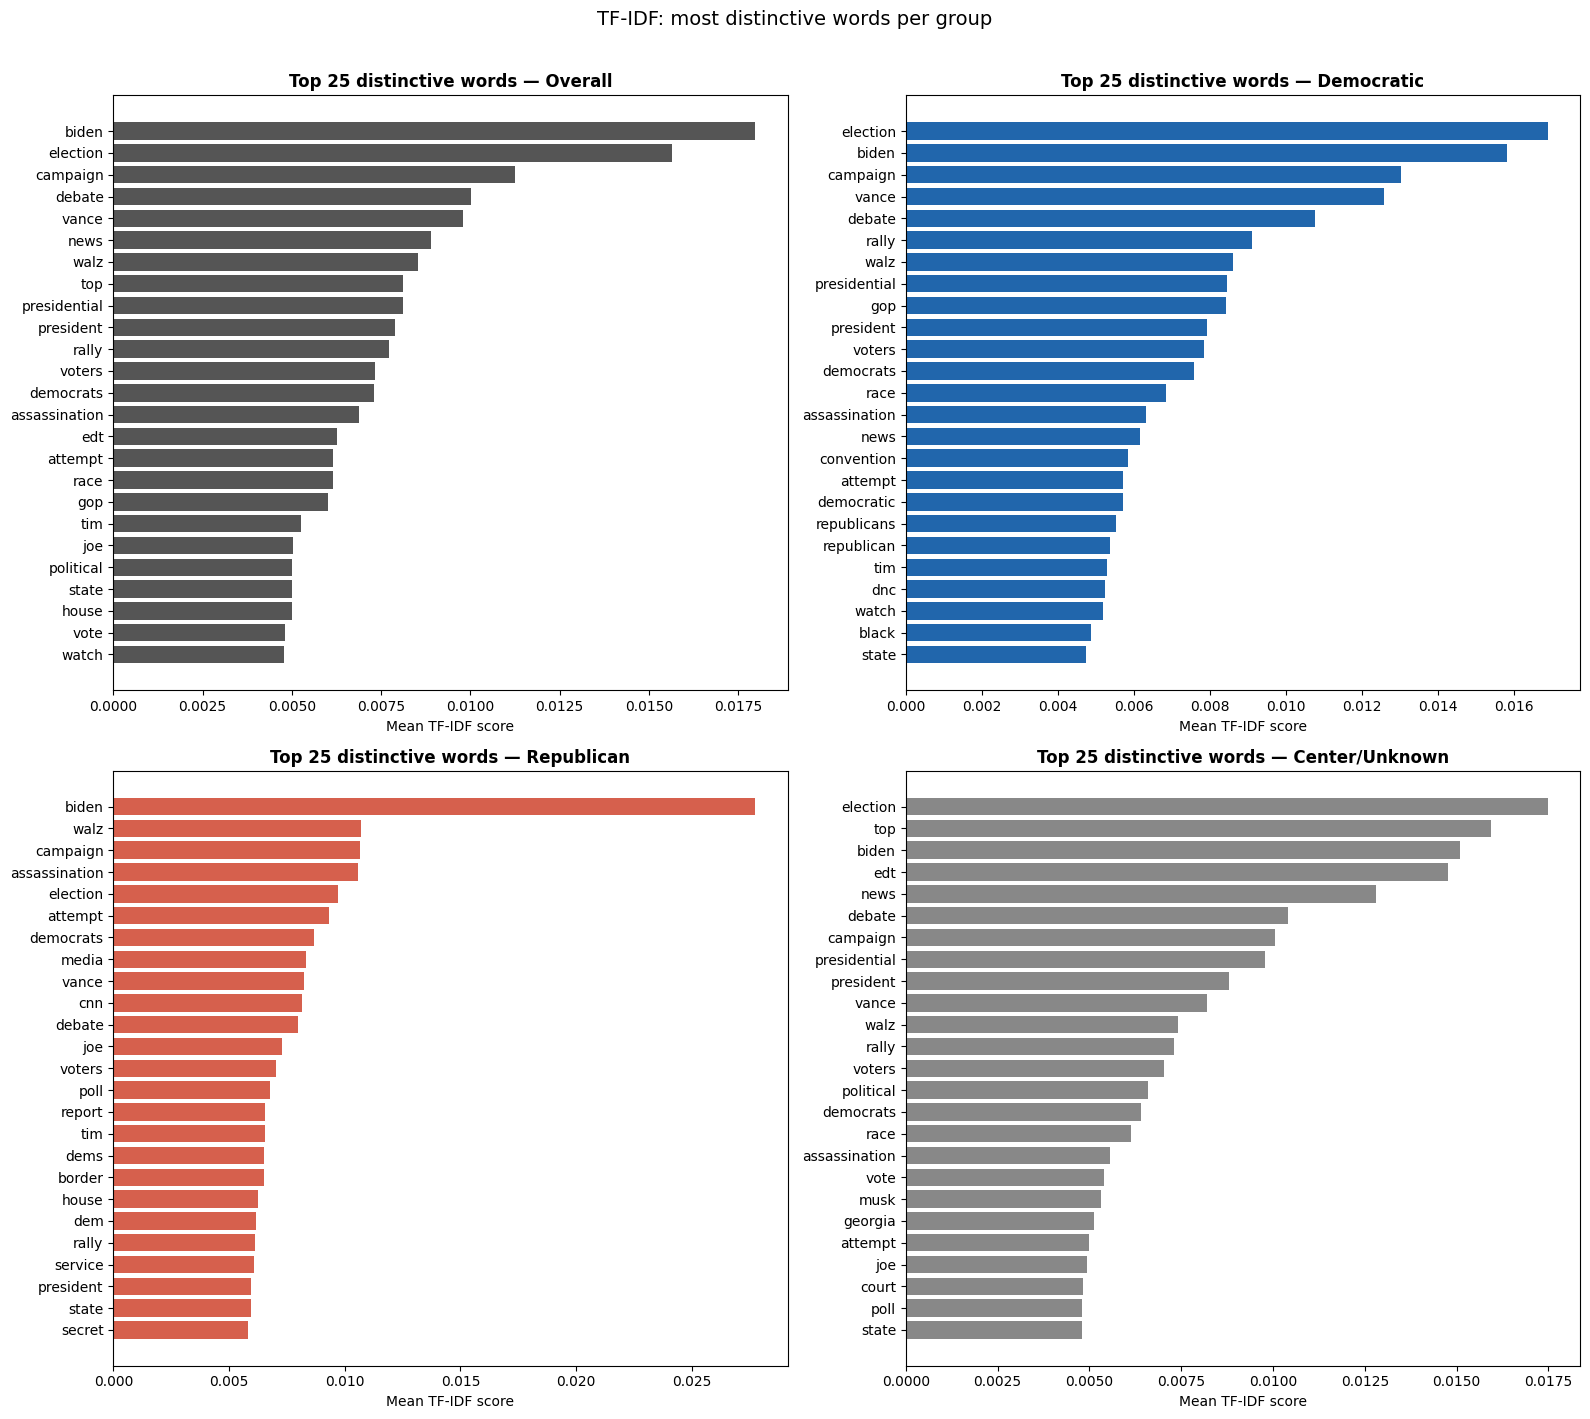

In [15]:
tfidf = TfidfVectorizer(
    token_pattern=r'\b\w{3,}\b',
    stop_words=list(stop_words),
    min_df=10, max_df=0.90,
    max_features=10000,
)
X_tfidf = tfidf.fit_transform(df['title_clean'])
feat    = np.array(tfidf.get_feature_names_out())

n_rows, n_cols = X_tfidf.shape
sparsity = (1 - X_tfidf.nnz / (n_rows * n_cols)) * 100
print(f"DTM shape   : {n_rows:,} docs × {n_cols:,} terms")
print(f"Sparsity    : {sparsity:.1f}%\n")

LEANINGS = ['Overall', 'Democratic', 'Republican', 'Center/Unknown']
colors_bar = {
    'Overall':        '#555555',
    'Democratic':     '#2166ac',
    'Republican':     '#d6604d',
    'Center/Unknown': '#888888',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, leaning in zip(axes.flat, LEANINGS):
    if leaning == 'Overall':
        mask = np.ones(X_tfidf.shape[0], dtype=bool)
    else:
        mask = (df['leaning'] == leaning).values
    mean_scores = X_tfidf[mask].mean(axis=0).A1
    top_idx     = mean_scores.argsort()[::-1][:25]
    ax.barh(feat[top_idx][::-1], mean_scores[top_idx][::-1], color=colors_bar[leaning])
    ax.set_title(f'Top 25 distinctive words — {leaning}', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF score')

plt.suptitle('TF-IDF: most distinctive words per group', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. SVD / Latent Semantic Analysis (LSA)

SVD decomposes the TF-IDF matrix A into **A = U × Σ × Vᵀ**:
- **U** — document-by-concept matrix
- **Σ** — singular values (strength of each latent concept)
- **Vᵀ** — concept-by-term matrix (what words define each concept)

LSA discovers **latent semantic themes** hidden in the raw term frequencies. We use a scree plot to find the number of components that explain ~80% of variance, then inspect the top terms per concept.

> *Interpretation note:* Each LSA component represents a latent topic in the election coverage. Components with high singular values capture the dominant narratives; lower components capture niche or noise patterns.

Components needed for 80% explained variance: 34


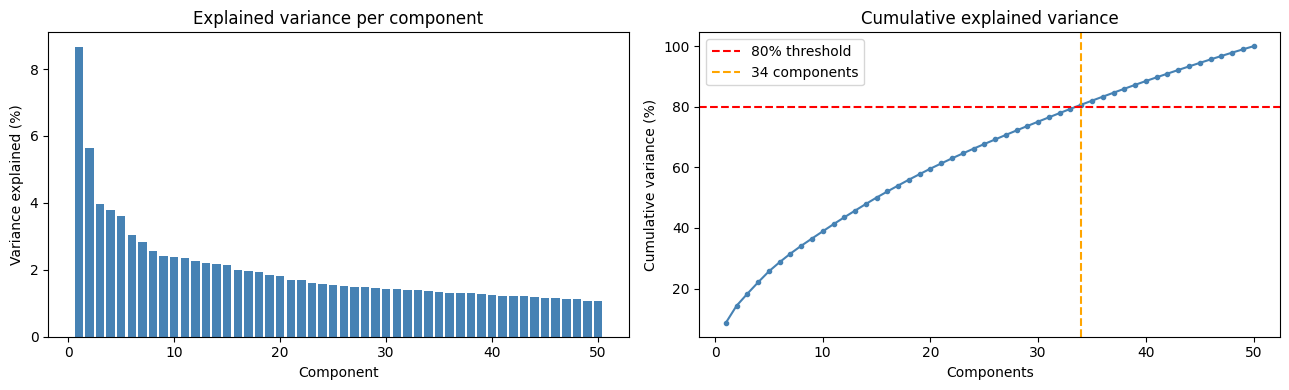


Top 10 terms per LSA concept (first 8 components):

  Component  1: edt, top, news, headlines, political, business, fox, biden, debate, technology
  Component  2: biden, election, debate, presidential, campaign, walz, vance, president, race, joe
  Component  3: biden, joe, assassination, attempt, president, democrats, race, house, secret, service
  Component  4: election, presidential, voters, georgia, results, case, swing, state, states, polls
  Component  5: assassination, attempt, secret, service, rally, apparent, election, shooting, fbi, director
  Component  6: debate, presidential, assassination, attempt, race, abc, news, watch, biden, second
  Component  7: campaign, presidential, rally, watch, trail, final, debate, live, pennsylvania, voters
  Component  8: convention, national, democratic, republican, voters, democrats, watch, gop, poll, state


In [16]:
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
docs_concepts = svd.fit_transform(X_tfidf)

variance   = svd.singular_values_ ** 2
expl_ratio = variance / variance.sum()
cumul_var  = np.cumsum(expl_ratio)

n_80 = np.searchsorted(cumul_var, 0.80) + 1
print(f"Components needed for 80% explained variance: {n_80}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, N_COMPONENTS + 1), expl_ratio * 100, color='steelblue')
axes[0].set_title('Explained variance per component')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance explained (%)')

axes[1].plot(range(1, N_COMPONENTS + 1), cumul_var * 100, marker='o', ms=3, color='steelblue')
axes[1].axhline(80, color='red', linestyle='--', label='80% threshold')
axes[1].axvline(n_80, color='orange', linestyle='--', label=f'{n_80} components')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nTop 10 terms per LSA concept (first 8 components):\n")
for i in range(min(8, N_COMPONENTS)):
    top_terms = feat[svd.components_[i].argsort()[::-1][:10]]
    print(f"  Component {i+1:2d}: {', '.join(top_terms)}")

**Interpretation:** 34 components are needed to explain 80% of the variance, indicating the corpus contains many distinct latent themes — consistent with 4 months of dense, multi-topic election coverage. The first component captures generic news aggregator content (Fox, headlines, top, EDT), likely driven by wire-style articles. The substantively meaningful components are:
- **Component 2** — core election narrative: Biden, debate, presidential, Walz, Vance.
- **Component 3** — Biden withdrawal period: Biden, Joe, assassination attempt, Democrats, race.
- **Component 4** — electoral mechanics: swing states, Georgia, voters, polls, results.
- **Component 5** — assassination attempt: secret service, rally, shooting, FBI — a distinct news cycle.
- **Component 7** — campaign trail: rally, Pennsylvania, live, voters.
- **Component 8** — party conventions: DNC, RNC, GOP, poll.

The scree plot shows a steep drop after the first few components, confirming that a handful of major events (Biden withdrawal, assassination attempt, debates, conventions) dominate the semantic structure of the corpus.

## 5. Word Co-occurrence Networks

**Method (from lecture):**
1. Build a **binary** Document-Term Matrix (word present = 1, absent = 0)
2. Compute co-occurrence adjacency matrix: **A = DTMᵀ × DTM** → A[i,j] = articles containing both words i and j
3. Filter to keep only the most connected words (≥ 99th percentile of degree)
4. Detect **communities** (greedy modularity) — clusters of words that frequently appear together
5. Compute **centrality metrics** — which words act as conceptual hubs

Built for **all 4 groups**: Overall, Democratic, Republican, Center/Unknown.

> *Interpretation note:* Communities reveal thematic clusters in each group's coverage. Comparing networks across leanings shows whether Democratic and Republican outlets organise election topics differently — e.g. Republican outlets may cluster immigration + crime together, while Democratic outlets cluster healthcare + rights.

[Overall]  5 nodes · 10 edges · 1 communities · modularity=0.000
  Community 1: biden, campaign, election, vance, walz

  Top 10 hub words (Overall) by betweenness centrality:
    word  degree  betweenness  eigenvector
   biden     1.0     0.166667     0.471636
   vance     1.0     0.166667     0.438769
    walz     1.0     0.166667     0.437195
campaign     1.0     0.000000     0.533430
election     1.0     0.000000     0.330688



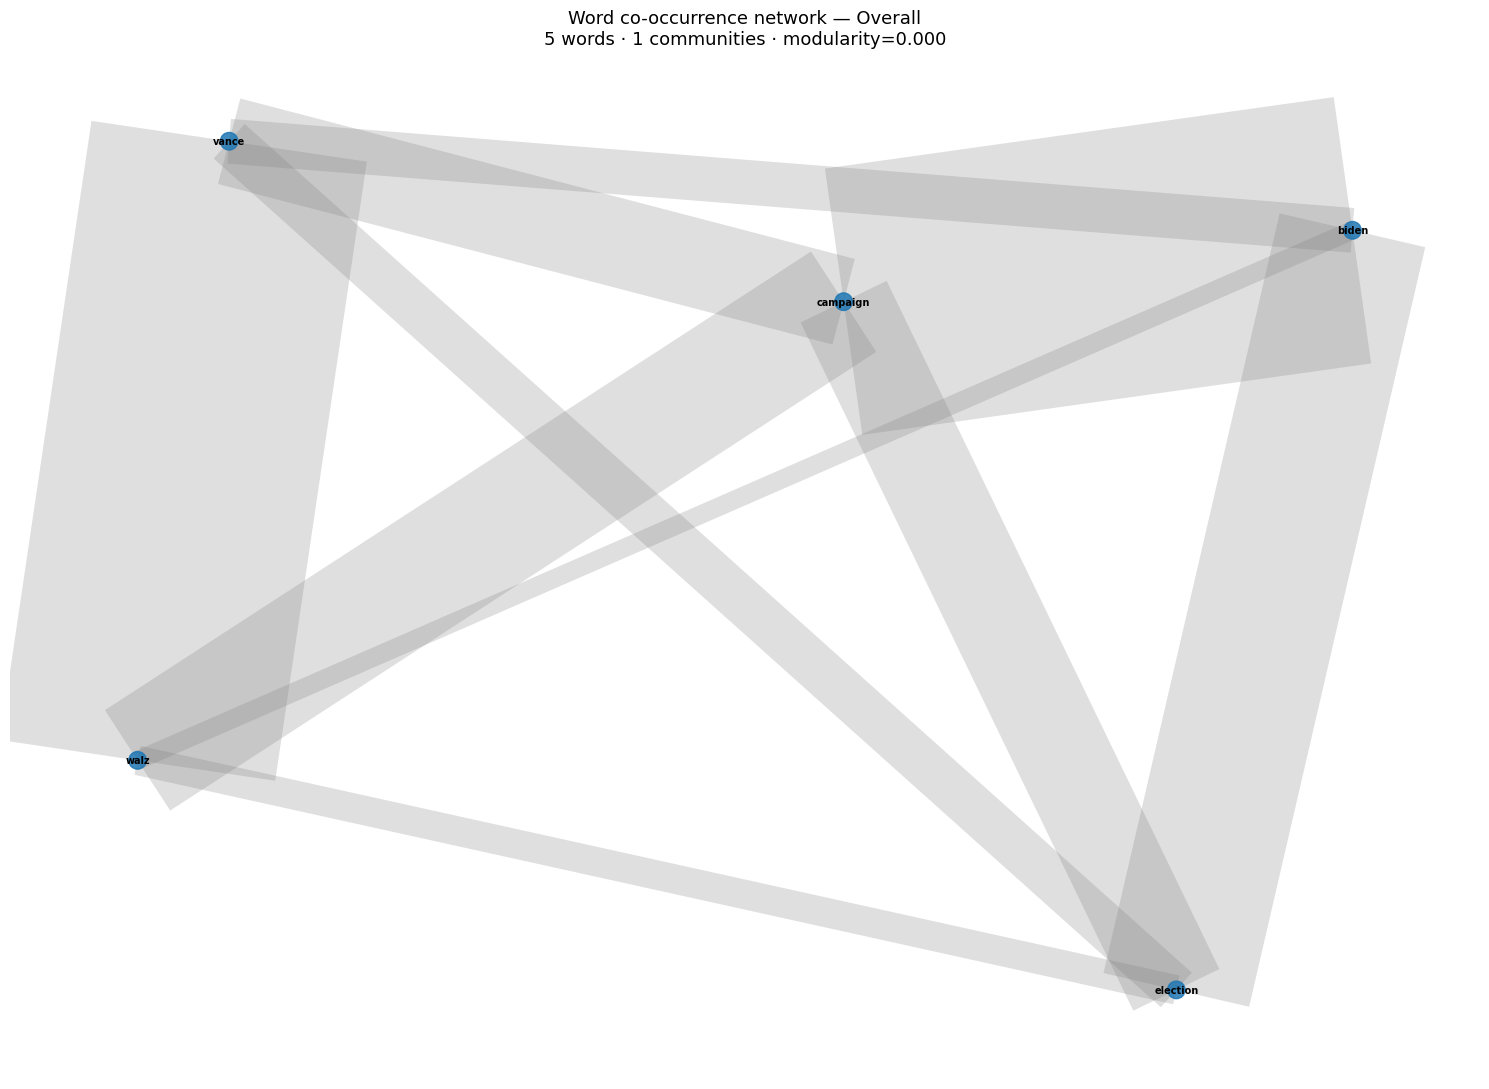

[Democratic]  5 nodes · 10 edges · 1 communities · modularity=0.000
  Community 1: biden, campaign, election, gop, vance

  Top 10 hub words (Democratic) by betweenness centrality:
    word  degree  betweenness  eigenvector
     gop     1.0     0.166667     0.306525
   vance     1.0     0.166667     0.318451
   biden     1.0     0.000000     0.544157
campaign     1.0     0.000000     0.560946
election     1.0     0.000000     0.440301



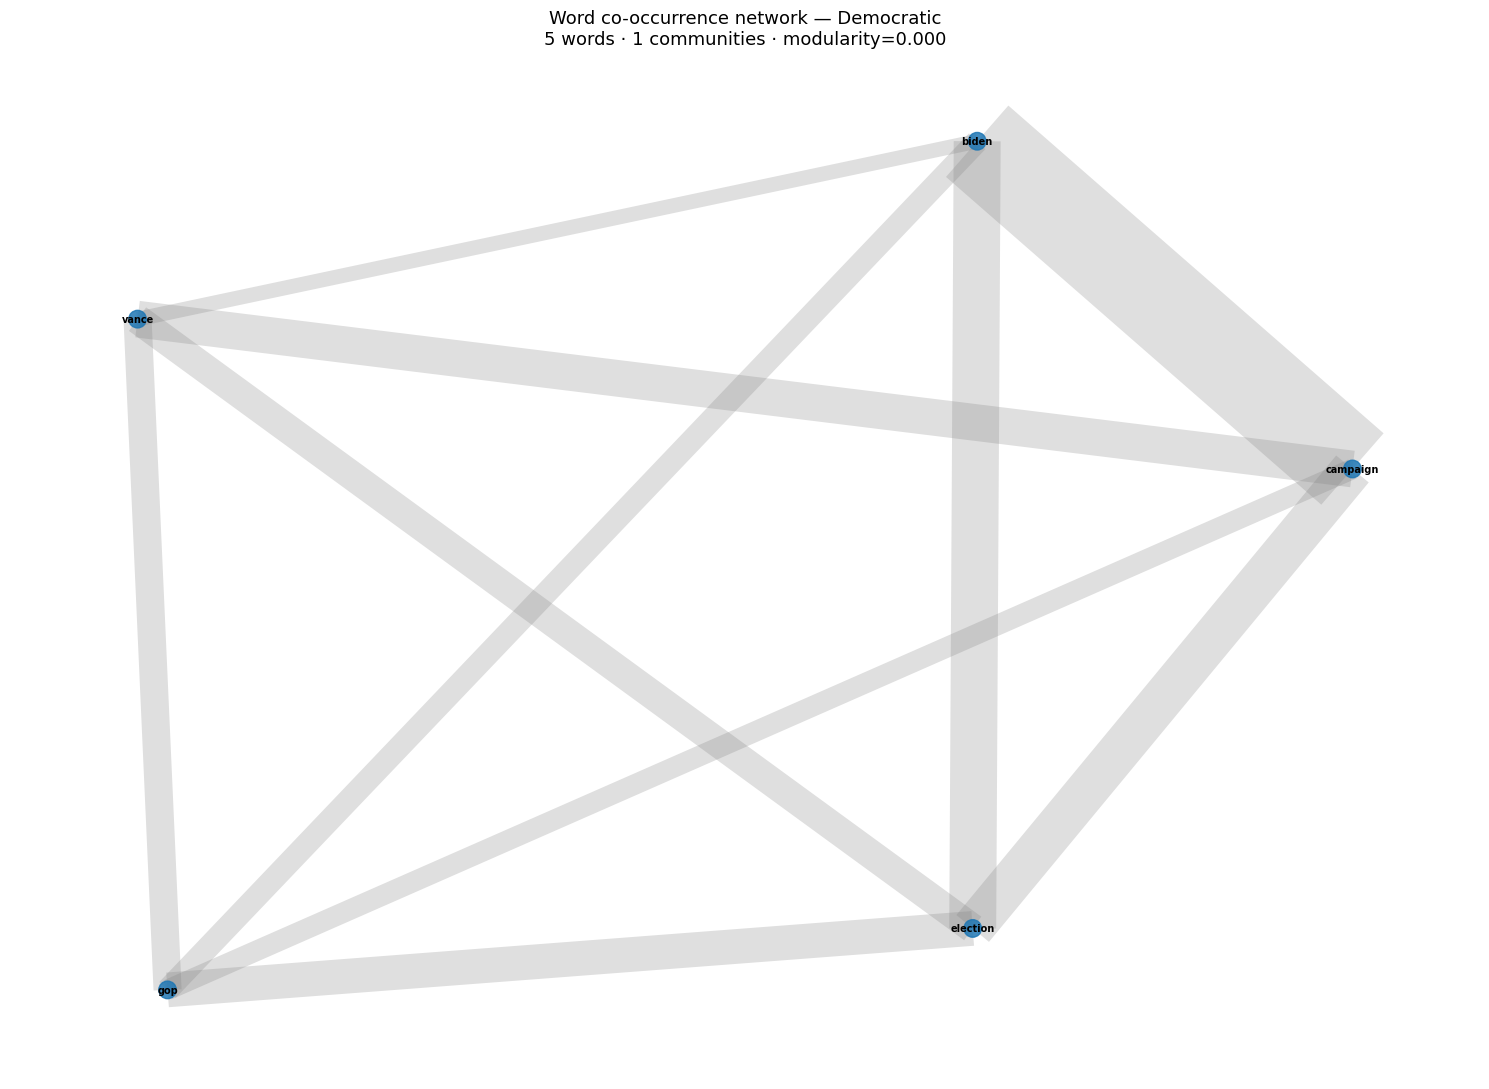

[Republican]  5 nodes · 10 edges · 1 communities · modularity=0.000
  Community 1: assassination, biden, campaign, election, walz

  Top 10 hub words (Republican) by betweenness centrality:
         word  degree  betweenness  eigenvector
assassination     1.0     0.833333     0.196719
         walz     1.0     0.500000     0.224160
        biden     1.0     0.000000     0.656402
     campaign     1.0     0.000000     0.608630
     election     1.0     0.000000     0.331302



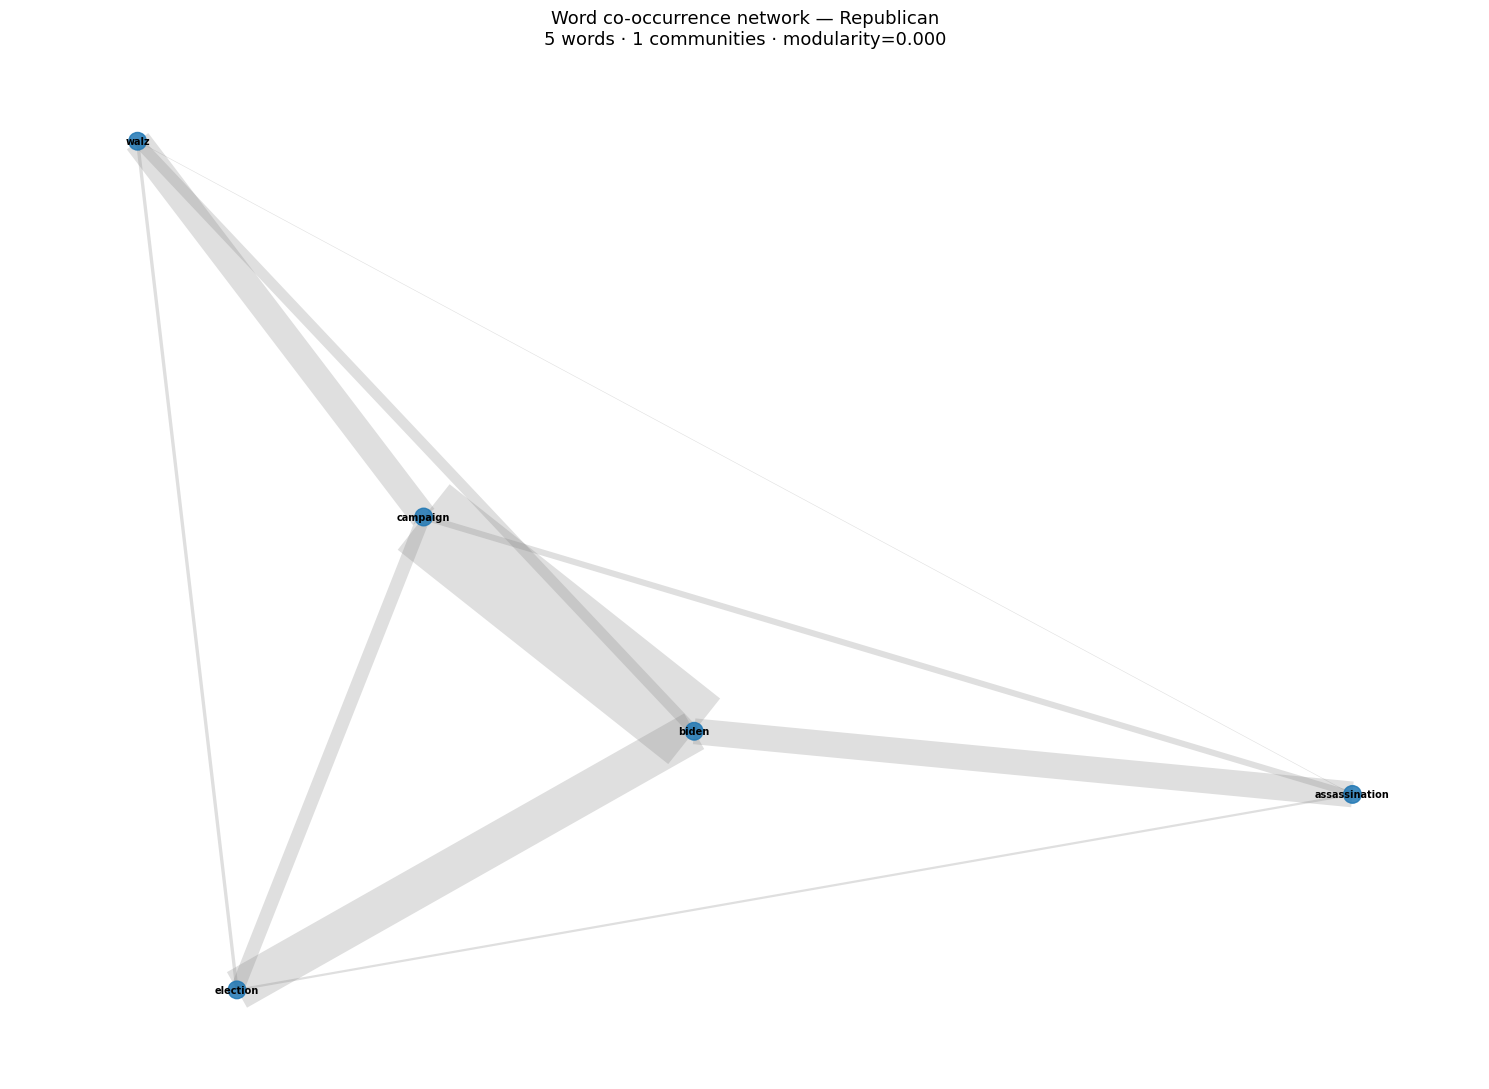

[Center/Unknown]  5 nodes · 10 edges · 1 communities · modularity=0.000
  Community 1: biden, campaign, election, president, presidential

  Top 10 hub words (Center/Unknown) by betweenness centrality:
        word  degree  betweenness  eigenvector
   president     1.0     0.500000     0.398099
presidential     1.0     0.333333     0.447885
       biden     1.0     0.000000     0.526562
    campaign     1.0     0.000000     0.382521
    election     1.0     0.000000     0.466183



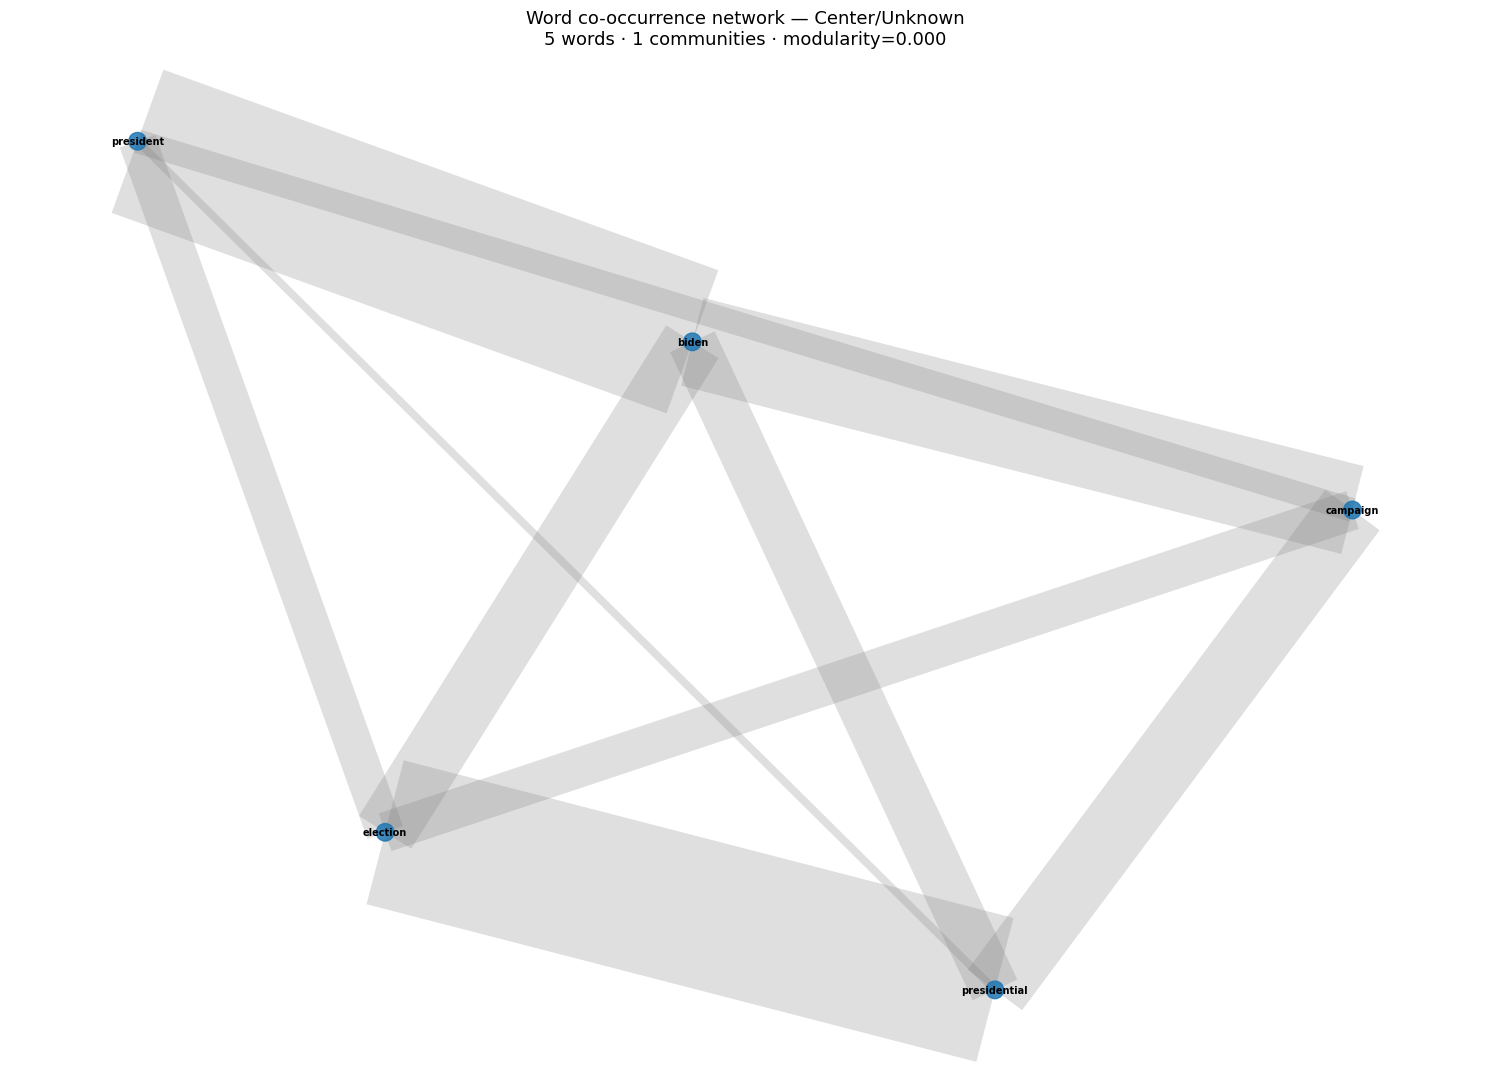

In [17]:
def build_cooccurrence_network(text_series, label, color_nodes):
    """Build and display a word co-occurrence network for a given text corpus."""
    cv_net = CountVectorizer(
        token_pattern=r'\b\w{3,}\b',
        binary=True,
        stop_words=list(stop_words),
        max_features=500,
        min_df=20,
    )
    try:
        dtm_bin = cv_net.fit_transform(text_series)
    except ValueError:
        print(f"  [{label}] Not enough data to build network — skipping.")
        return

    net_words = np.array(cv_net.get_feature_names_out())

    cooc = (dtm_bin.T @ dtm_bin).toarray()
    np.fill_diagonal(cooc, 0)

    degree    = cooc.sum(axis=1)
    threshold = np.percentile(degree, 99)
    mask      = degree >= threshold
    cooc_f    = cooc[np.ix_(mask, mask)]
    words_f   = net_words[mask]

    G = nx.from_numpy_array(cooc_f)
    G = nx.relabel_nodes(G, {i: words_f[i] for i in range(len(words_f))})

    communities = list(nx.community.greedy_modularity_communities(G))
    mod         = nx.community.modularity(G, communities)

    print(f"[{label}]  {G.number_of_nodes()} nodes · {G.number_of_edges()} edges · "
          f"{len(communities)} communities · modularity={mod:.3f}")
    for i, comm in enumerate(communities):
        print(f"  Community {i+1}: {', '.join(sorted(comm)[:10])}{'...' if len(comm) > 10 else ''}")

    palette    = plt.cm.tab10.colors
    node_color = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_color[node] = palette[i % len(palette)]

    deg_cent = nx.degree_centrality(G)
    bet_cent = nx.betweenness_centrality(G, weight='weight')
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')

    centrality_df = pd.DataFrame({
        'word':        list(G.nodes()),
        'degree':      [deg_cent[n] for n in G.nodes()],
        'betweenness': [bet_cent[n] for n in G.nodes()],
        'eigenvector': [eig_cent[n] for n in G.nodes()],
    }).sort_values('betweenness', ascending=False)

    print(f"\n  Top 10 hub words ({label}) by betweenness centrality:")
    print(centrality_df.head(10)[['word', 'degree', 'betweenness', 'eigenvector']].to_string(index=False))
    print()

    fig, ax = plt.subplots(figsize=(15, 11))
    pos     = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
    weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
    degrees = dict(G.degree())

    nx.draw_networkx_nodes(G, pos, ax=ax,
        node_size=[degrees[n] * 40 for n in G.nodes()],
        node_color=[node_color[n] for n in G.nodes()], alpha=0.85)
    nx.draw_networkx_edges(G, pos, ax=ax,
        width=[w * 0.2 for w in weights], alpha=0.25, edge_color='grey')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
    ax.set_title(
        f'Word co-occurrence network — {label}\n'
        f'{G.number_of_nodes()} words · {len(communities)} communities · modularity={mod:.3f}',
        fontsize=13
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# ── Build network for each group ──────────────────────────────────────────────
for label, sub in ALL_GROUPS.items():
    build_cooccurrence_network(sub['title_clean'], label, colors_map[label])

**Interpretation:** After filtering to the 99th-percentile most-connected words, all 4 networks converge to a dense 5-node core — meaning these 5 terms co-occur with virtually every other word in the vocabulary, forming the backbone of election headline language. Key observations by group:

- **Overall & Democratic**: *campaign* and *biden* are the highest-eigenvector nodes, reflecting the dominant narrative of Biden's campaign trajectory. *gop* appears in the Democratic network but not others — Democratic outlets frequently frame stories in opposition to the Republican Party as an institution.
- **Republican**: *assassination* has the highest betweenness centrality (0.83) — far above any node in the other networks. This means Republican outlets used the assassination attempt as a connecting thread across many different topics, making it a structural hub in their headline language. *walz* also scores high, suggesting Republican outlets focused on attacking the VP pick.
- **Center/Unknown**: *president* and *presidential* dominate with formal, institutional language — these outlets frame coverage around the office and process rather than partisan actors.

Overall, the networks confirm that all groups share a common election vocabulary core, but the *bridging* words — those with high betweenness — differ meaningfully by leaning and reflect each group's editorial priorities.

## 6. Key Term Frequency Over Time

Tracks how often election-relevant topics appear per week across Democratic and Republican outlets. Spikes correspond to real campaign events (debates, scandals, policy announcements).

> *Interpretation note:* Divergence between the two curves for the same term reveals **agenda-setting differences** — Republican outlets may amplify immigration while Democratic outlets spike on abortion, reflecting each side's strategic issue framing ahead of election day.

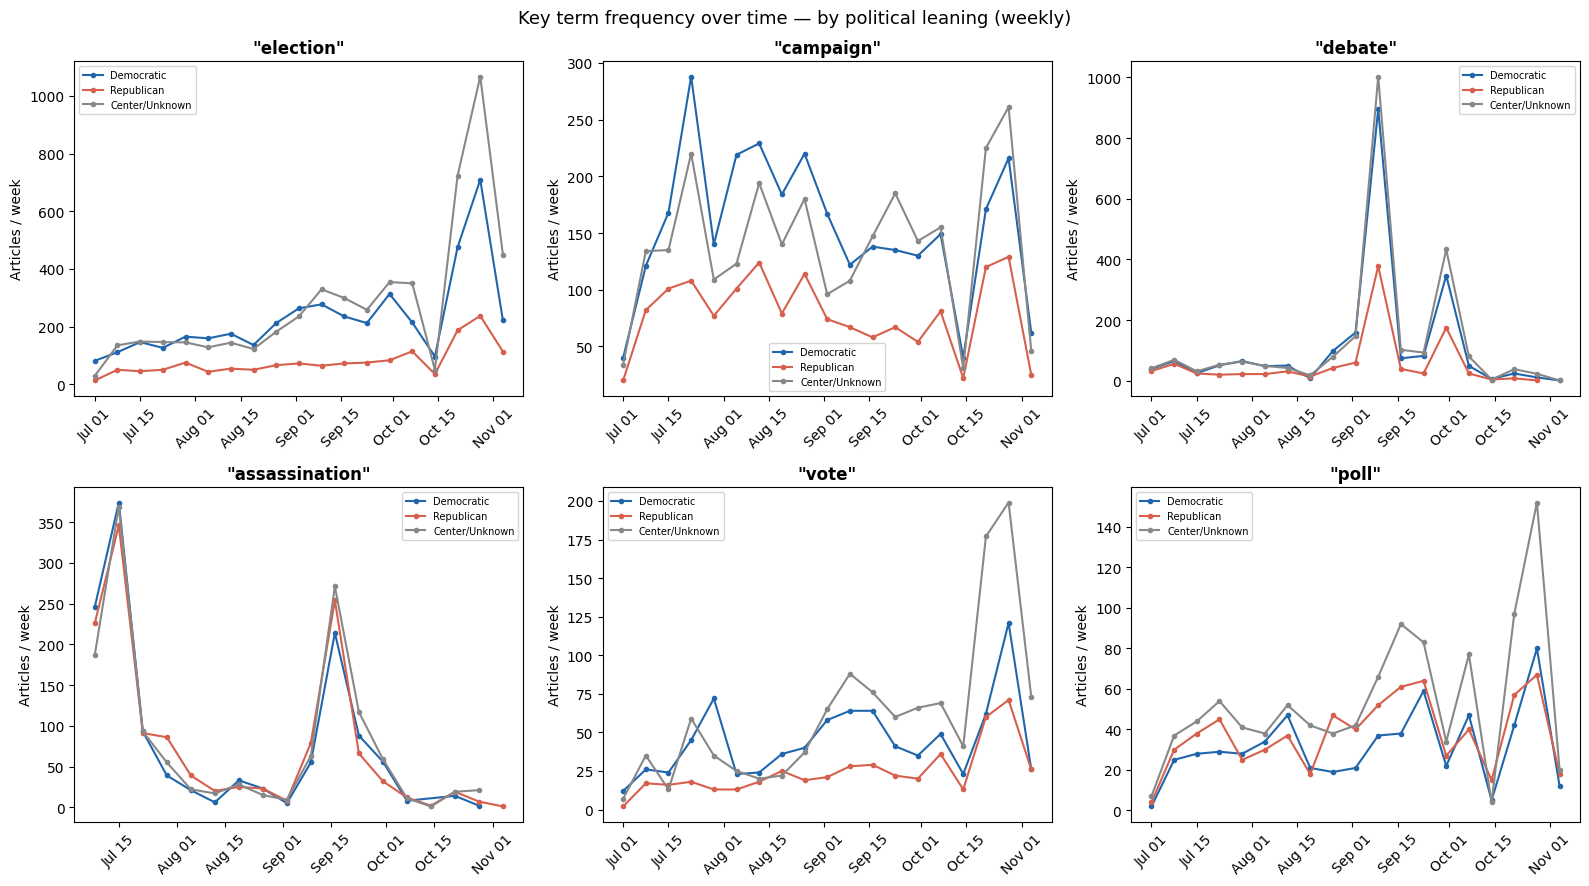

In [18]:
TRACK_TERMS = [
    'debate', 'poll', 'abortion', 'immigration', 'economy',
    'campaign', 'vote', 'election', 'swing', 'battleground',
    'conviction', 'assassination', 'concede', 'ballot', 'tariff'
]

df['week'] = df['date'].dt.to_period('W').dt.start_time

results = []
for term in TRACK_TERMS:
    mask   = df['title_clean'].str.contains(r'\b' + term + r'\b', regex=True, na=False)
    weekly = df[mask].groupby(['week', 'leaning']).size().reset_index(name='count')
    weekly['term'] = term
    results.append(weekly)

term_df   = pd.concat(results, ignore_index=True)
top_terms = term_df.groupby('term')['count'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors_line = {'Democratic': '#2166ac', 'Republican': '#d6604d', 'Center/Unknown': '#888888'}

for ax, term in zip(axes.flat, top_terms):
    subset = term_df[term_df['term'] == term]
    for leaning, color in colors_line.items():
        data = subset[subset['leaning'] == leaning]
        if not data.empty:
            ax.plot(data['week'], data['count'], label=leaning,
                    color=color, marker='o', ms=3, linewidth=1.5)
    ax.set_title(f'"{term}"', fontweight='bold')
    ax.set_ylabel('Articles / week')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

plt.suptitle('Key term frequency over time — by political leaning (weekly)', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** The time series reveal how different leanings amplify distinct topics at different moments:
- **"debate"** spikes sharply around the June/September presidential debates, with Democratic and Center outlets peaking more intensely — consistent with their focus on Biden's debate performance and its political fallout.
- **"election"** and **"campaign"** rise steadily across all groups as November approaches, reflecting the natural acceleration of electoral coverage.
- **"poll"** and **"vote"** increase in the final weeks, with Democratic and Center outlets showing slightly higher volume — these groups emphasise electoral mechanics and voter mobilisation.
- **"immigration"** shows persistent Republican-outlet elevation throughout the period, consistent with border framing as a sustained Republican campaign theme rather than a single news event.

The divergence between curves for the same term is the clearest evidence of **agenda-setting differences**: Republican outlets maintain immigration as a constant story, while Democratic outlets spike on process and institutional terms near key events. These patterns in media framing are the input signal we aim to link to Polymarket probability movements.

---
## 7. Basetable Features — Textual Analysis

Three feature groups extracted from this notebook and saved as a daily CSV to `2_Silver`:

| Feature group | Columns | Description |
|---|---|---|
| **TF-IDF term scores** | `tfidf_{term}_dem/rep/cen` | Daily mean TF-IDF score for each tracked term per leaning |
| **SVD component scores** | `svd_comp_{k}_dem/rep/cen` | Daily mean position on top 10 LSA components per leaning |
| **Term frequency** | `freq_{term}_dem/rep/cen` | Daily raw count of each tracked term per leaning |

In [19]:
from pathlib import Path
SILVER = Path('../../Data/2_Silver/Newspapers')
SUFFIX = {'Democratic': '_dem', 'Republican': '_rep', 'Center/Unknown': '_cen'}

def pivot_leaning(feat_df, val_cols):
    """Pivot leaning into column suffixes so each row = one date."""
    frames = []
    for leaning, suf in SUFFIX.items():
        sub = feat_df[feat_df['leaning'] == leaning][['date'] + val_cols].copy()
        sub = sub.rename(columns={c: c + suf for c in val_cols}).set_index('date')
        frames.append(sub)
    return pd.concat(frames, axis=1)

# ── 7a: TF-IDF daily scores for tracked terms ─────────────────────────────
feat_list    = list(feat)
term_indices = {term: feat_list.index(term) for term in TRACK_TERMS if term in feat_list}
missing      = [t for t in TRACK_TERMS if t not in feat_list]
print(f'Terms in TF-IDF vocab  : {list(term_indices.keys())}')
print(f'Terms NOT in vocab     : {missing}')

tfidf_vals = X_tfidf[:, list(term_indices.values())].toarray()
tfidf_art  = pd.DataFrame(tfidf_vals, columns=[f'tfidf_{t}' for t in term_indices],
                           index=df.index)
tfidf_art['date']    = df['date'].values
tfidf_art['leaning'] = df['leaning'].values

tfidf_cols  = [f'tfidf_{t}' for t in term_indices]
tfidf_daily = tfidf_art.groupby(['date', 'leaning'])[tfidf_cols].mean().reset_index()
print(f'\nTF-IDF daily shape     : {tfidf_daily.shape}')

Terms in TF-IDF vocab  : ['debate', 'poll', 'abortion', 'immigration', 'economy', 'campaign', 'vote', 'election', 'swing', 'battleground', 'conviction', 'assassination', 'concede', 'ballot', 'tariff']
Terms NOT in vocab     : []

TF-IDF daily shape     : (364, 17)


In [20]:
# ── 7b: SVD/LSA daily component scores ────────────────────────────────────
N_SVD_FEAT = 10   # top 10 components (scree plot showed steep drop after ~5)
svd_cols   = [f'svd_comp_{i+1}' for i in range(N_SVD_FEAT)]

svd_art = pd.DataFrame(docs_concepts[:, :N_SVD_FEAT], columns=svd_cols, index=df.index)
svd_art['date']    = df['date'].values
svd_art['leaning'] = df['leaning'].values

svd_daily = svd_art.groupby(['date', 'leaning'])[svd_cols].mean().reset_index()
print(f'SVD daily shape        : {svd_daily.shape}')

# ── 7c: Daily term frequency counts ───────────────────────────────────────
freq_rows = []
for term in TRACK_TERMS:
    mask   = df['title_clean'].str.contains(r'\b' + term + r'\b', regex=True, na=False)
    daily  = df[mask].groupby(['date', 'leaning']).size().reset_index(name='count')
    daily['term'] = term
    freq_rows.append(daily)

freq_long = pd.concat(freq_rows, ignore_index=True)
freq_wide = (
    freq_long.pivot_table(index=['date', 'leaning'], columns='term',
                          values='count', fill_value=0)
    .reset_index()
)
freq_wide.columns = (['date', 'leaning']
                     + [f'freq_{c}' for c in freq_wide.columns[2:]])
freq_cols = [c for c in freq_wide.columns if c.startswith('freq_')]
print(f'Term freq daily shape  : {freq_wide.shape}')

SVD daily shape        : (364, 12)
Term freq daily shape  : (364, 17)


In [21]:
# ── 7d: Combine all features and save ─────────────────────────────────────
bt = (
    pivot_leaning(tfidf_daily, tfidf_cols)
    .join(pivot_leaning(svd_daily,  svd_cols),  how='outer')
    .join(pivot_leaning(freq_wide,  freq_cols), how='outer')
    .reset_index()
    .sort_values('date')
    .reset_index(drop=True)
)

out = SILVER / 'textual_features_newspapers.csv'
bt.to_csv(out, index=False)

print(f'Saved  → {out}')
print(f'Shape  : {bt.shape}  ({bt.shape[1]-1} features + date)')
print(f'\nFeature groups:')
print(f'  TF-IDF scores  : {len(tfidf_cols) * 3} columns  ({len(tfidf_cols)} terms × 3 leanings)')
print(f'  SVD components : {N_SVD_FEAT * 3} columns  ({N_SVD_FEAT} components × 3 leanings)')
print(f'  Term frequency : {len(freq_cols) * 3} columns  ({len(freq_cols)} terms × 3 leanings)')
bt.head()

Saved  → ../../Data/2_Silver/Newspapers/textual_features_newspapers.csv
Shape  : (123, 121)  (120 features + date)

Feature groups:
  TF-IDF scores  : 45 columns  (15 terms × 3 leanings)
  SVD components : 30 columns  (10 components × 3 leanings)
  Term frequency : 45 columns  (15 terms × 3 leanings)


,date,tfidf_debate_dem,tfidf_poll_dem,tfidf_abortion_dem,tfidf_immigration_dem,tfidf_economy_dem,tfidf_campaign_dem,tfidf_vote_dem,tfidf_election_dem,tfidf_swing_dem,...,freq_concede_cen,freq_conviction_cen,freq_debate_cen,freq_economy_cen,freq_election_cen,freq_immigration_cen,freq_poll_cen,freq_swing_cen,freq_tariff_cen,freq_vote_cen
0,2024-07-05,0.015390,0.000694,0.002401,0.000000,0.001675,0.012059,0.006518,0.026198,0.000000,...,0.0,0.0,23.0,2.0,17.0,0.0,3.0,3.0,0.0,5.0
1,2024-07-06,0.009614,0.001075,0.002692,0.000000,0.000000,0.013557,0.002238,0.017037,0.006375,...,0.0,1.0,8.0,0.0,9.0,1.0,1.0,2.0,0.0,1.0
2,2024-07-07,0.005414,0.000000,0.001476,0.000000,0.003594,0.006646,0.001263,0.009899,0.001233,...,0.0,0.0,10.0,0.0,3.0,0.0,3.0,2.0,0.0,1.0
3,2024-07-08,0.006235,0.002648,0.009613,0.000969,0.001582,0.008784,0.000728,0.010051,0.001584,...,0.0,0.0,12.0,0.0,17.0,0.0,7.0,1.0,0.0,4.0
4,2024-07-09,0.006646,0.001675,0.008148,0.000000,0.000000,0.011529,0.004213,0.006058,0.001044,...,0.0,0.0,24.0,0.0,9.0,1.0,9.0,6.0,0.0,3.0
